Фармацевтическая кампания утверждает, что в одной капсуле лекарства содержится 500 мг активного вещества. Известно что отклонение активного вещества равно 15 мг.

Для тестирования отобрали 100 случайных капсул. Необходимо на уровне значимости 5% проверить, является ли среднее количетво действующего вещества 500 мг.

**Нулевая гипотеза:** в одной капсуле в среднем 500 мг.</br>
**Альтернативная гипотеза:** в одной капсуле в среднем не 500 мг.


In [2]:
from scipy import stats as sts
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.stats import weightstats as stests

In [6]:
np.random.seed(0)

mu_0 = 500 #Гипотетическое среднее (Ho). Количество мг в капсуле лекарства
print(f'Среднее предполагаемое количество грамм: {mu_0}')
sigma = 15 #Стандартное отклонение для ГС

data = np.random.normal(loc=mu_0, scale=15, size=100) #Значения выборки
n = 100 #Размер выборки

x_bar = np.mean(data) #Среднее выборки
se = sigma/(np.sqrt(n)) #Стандартная ошибка
z_crit = 1.96
margin_of_error = z_crit*se
#ДИ для mu_0
lower_bound = x_bar - margin_of_error
upper_bound = x_bar + margin_of_error
print(f'Среднее выборочное количество грамм: {x_bar:.2f}')
print(f'95-й доверительный интервал: [{lower_bound:.2f}-{upper_bound:.2f}]')

Среднее предполагаемое количество грамм: 500
Среднее выборочное количество грамм: 500.90
95-й доверительный интервал: [497.96-503.84]


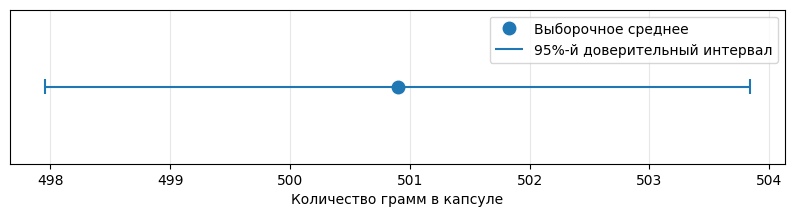

In [7]:
plt.figure(figsize=(10, 2))
plt.plot(x_bar, 0, 'o', markersize=9, label='Выборочное среднее')
plt.hlines(y=0, xmin=lower_bound, xmax=upper_bound, label='95%-й доверительный интервал')
plt.vlines(x=lower_bound, ymin=-0.1, ymax=0.1)
plt.vlines(x=upper_bound, ymin=-0.1, ymax=0.1)
plt.ylim(-1, 1)

plt.grid(True, alpha=0.3)
plt.yticks([])
plt.xlabel('Количество грамм в капсуле')
plt.legend()
plt.show()

In [9]:
z_statistic, p_value = stests.ztest(x1=data, value=mu_0) #Имеем значения выборки

print(f'z-критичская: {z_crit:.2f}')
print(f'z-statistic: {z_statistic:.2f}')
print(f'p‑value: {p_value:.2f}')

z-критичская: 1.96
z-statistic: 0.59
p‑value: 0.55


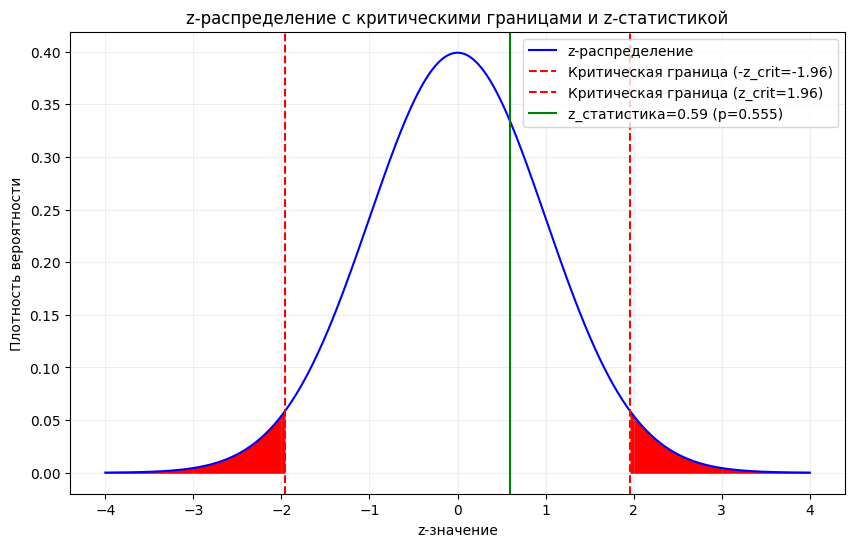

In [10]:
#Значения для кривой
x = np.linspace(-4, 4, 1000)
y = sts.norm.pdf(x)

#Генерация графика
plt.figure(figsize=(10, 6))
plt.plot(x, y, label=f'z-распределение', color='b')

#Линии критических границ
plt.axvline(x=-z_crit, label=f'Критическая граница (-z_crit={-z_crit:.2f})' , linestyle='--', color='r')
plt.axvline(x=z_crit, label=f'Критическая граница (z_crit={z_crit:.2f})', linestyle='--', color='r')

#Линия t-статистики
plt.axvline(x=z_statistic, label=f'z_статистика={z_statistic:.2f} (p={p_value:.3f})', linestyle='-', color='g')

#Участки отвержения нулевой гипотезы
plt.fill_between(x,y, where=(x>=z_crit), color='r')
plt.fill_between(x,y, where=(x<=-z_crit), color='r')

plt.title('z-распределение с критическими границами и z-статистикой')
plt.xlabel('z-значение')
plt.ylabel('Плотность вероятности')

plt.grid(True, alpha=0.2)
plt.legend()
plt.show()

Наблюдаемая z-статистика=0.59, что выше критического значения 1.96. Из этого мы делаем вывод что она не попадет в критическую область. Нет оснований отвергать H-нулевое.</br>
P-value=0.55 то есть в 55% случаев при верном H-нулевом встречаются такие же или ещё более сильные отклонения, что намного выше порога в 5%. Нет оснований отвергать H-нулевое.</br>

Так как оба критерия согласуются, нет достаточных доказательств для опровержения нулевой гипотезы.